In [1]:
import os
import re
import copy
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

mp.set_sharing_strategy("file_system")

# =========================
# Configuration
# =========================
BASE_DIR = "./"
DATA_PATH = os.path.join(BASE_DIR, "data_physics_with_variances_total.csv")

# Output paths for the Full Scratch Model
BEST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scratch_7feat_best_5M.pth"
)
LAST_MODEL_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scratch_7feat_last_5M.pth"
)
SCALER_SAVE_PATH = os.path.join(
    BASE_DIR, "ber_boundedloghalf_globalboth_scalers_scratch_7feat_5M.pkl"
)
EPS = 1e-12
LOG10_HALF = float(np.log10(0.5))

# =========================
# Utilities
# =========================
def get_sorted_seq_cols(columns, prefix):
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    matched = []
    for col in columns:
        m = pattern.match(col)
        if m:
            matched.append((int(m.group(1)), col))
    matched.sort(key=lambda x: x[0])
    return [col for _, col in matched]

def make_strat_bins(y_log, n_bins=10):
    y_flat = y_log.reshape(-1)
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.quantile(y_flat, quantiles)
    edges = np.unique(edges)
    if len(edges) < 3:
        return None
    bins = np.digitize(y_flat, edges[1:-1], right=True)
    counts = np.bincount(bins)
    if np.any(counts < 2):
        return None
    return bins

def has_nonfinite_tensor(x):
    return not torch.isfinite(x).all().item()

# =========================
# Stable Multi-objective Loss (4-Tier)
# =========================
class StableMultiObjectiveBERBoundedLogLoss(nn.Module):
    """
    Stable multi-objective loss for BER constrained to (0, 0.5]:
    - model outputs unconstrained raw scalar u
    - u is mapped to: pred_log = log10(0.5) - softplus(u)
    - pred_raw = 10 ** pred_log
    - Huber loss in log10(BER) space
    - Huber loss in raw BER space
    - 4-tier regime weighting based on raw BER (low, mid, high, extreme)
    """
    def __init__(
        self,
        log_delta=0.5,
        raw_delta=0.5,     
        alpha_log=0.3,     
        beta_raw=0.7,      
        use_regime_weights=False,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      
        w_low=0.5,
        w_mid=2.5,         
        w_high=3.0,
        w_ext=8.0,         
    ):
        super().__init__()
        self.log_delta = log_delta
        self.raw_delta = raw_delta
        self.alpha_log = alpha_log
        self.beta_raw = beta_raw
        
        self.use_regime_weights = use_regime_weights
        self.low_thr = low_thr
        self.mid_thr = mid_thr
        self.ext_thr = ext_thr
        
        self.w_low = w_low
        self.w_mid = w_mid
        self.w_high = w_high
        self.w_ext = w_ext

    @staticmethod
    def huber_elementwise(pred, target, delta):
        err = pred - target
        abs_err = err.abs()
        return torch.where(
            abs_err < delta, 0.5 * err * err, delta * (abs_err - 0.5 * delta)
        )

    @staticmethod
    def raw_to_pred_log(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_pred_ber(pred_raw_unconstrained):
        pred_log = StableMultiObjectiveBERBoundedLogLoss.raw_to_pred_log(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, pred_raw_unconstrained, target_log):
        pred_log = self.raw_to_pred_log(pred_raw_unconstrained)
        pred_raw = torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)
        target_raw = torch.pow(10.0, target_log).clamp(min=EPS, max=0.5)
        target_log_for_loss = torch.log10(target_raw)

        log_loss = self.huber_elementwise(
            pred_log, target_log_for_loss, self.log_delta
        )
        raw_loss = self.huber_elementwise(pred_raw, target_raw, self.raw_delta)

        total = self.alpha_log * log_loss + self.beta_raw * raw_loss

        if self.use_regime_weights:
            weights = torch.full_like(target_raw, self.w_ext)
            weights = torch.where(
                target_raw < self.ext_thr, torch.full_like(weights, self.w_high), weights
            )
            weights = torch.where(
                target_raw < self.mid_thr, torch.full_like(weights, self.w_mid), weights
            )
            weights = torch.where(
                target_raw < self.low_thr, torch.full_like(weights, self.w_low), weights
            )
            total = total * weights

        return total.mean()

# =========================
# Blocks
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Conv1d(channels, hidden, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden, channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        scale = self.pool(x)
        scale = self.fc(scale)
        return x * scale

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(
                in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1 = out_ch // 3
        b2 = out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, kernel_size=3, dilation=1)
        self.branch2 = ConvBNAct(in_ch, b2, kernel_size=5, dilation=1)
        self.branch3 = ConvBNAct(in_ch, b3, kernel_size=3, dilation=2)
        self.mix = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.Dropout(dropout)
        )
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = (
            nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
                nn.BatchNorm1d(out_ch)
            ) if in_ch != out_ch else nn.Identity()
        )
        self.out_act = nn.GELU()

    def forward(self, x):
        residual = self.skip(x)
        out = torch.cat(
            [self.branch1(x), self.branch2(x), self.branch3(x)], dim=1
        )
        out = self.mix(out)
        out = self.se(out)
        out = out + residual
        out = self.out_act(out)
        return out

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(
            in_ch, out_ch, dropout=dropout, se=se
        )
        self.down = nn.Sequential(
            nn.Conv1d(
                out_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm1d(out_ch),
            nn.GELU()
        )

    def forward(self, x):
        x = self.pre(x)
        x = self.down(x)
        return x

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(condition_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, feature_dim * 2)
        )
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))

    def forward(self, x, cond):
        gamma_beta = self.net(cond)
        gamma, beta = torch.chunk(gamma_beta, 2, dim=1)
        gamma = gamma.unsqueeze(-1)
        beta = beta.unsqueeze(-1)
        return x * (1.0 + self.scale * gamma) + self.scale * beta

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(
            ConvBNAct(in_ch, stem_ch, kernel_size=5),
            MultiScaleResidualBlock(
                stem_ch, stem_ch, dropout=0.05, se=True
            )
        )

    def forward(self, x):
        return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        x_seq = x_seq + self.mlp(self.norm2(x_seq))
        return x_seq.transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(input_dim, attn_dim, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(attn_dim, num_heads, kernel_size=1)
        )
        self.num_heads = num_heads
        self.input_dim = input_dim

    def forward(self, x):
        logits = self.score(x)
        weights = torch.softmax(logits, dim=-1)
        pooled = torch.einsum("bhl,bcl->bhc", weights, x)
        pooled = pooled.reshape(x.size(0), self.num_heads * self.input_dim)
        return pooled

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(
            input_dim=channels, attn_dim=attn_dim, num_heads=num_attn_heads
        )
        self.out_dim = num_attn_heads * channels + 3 * channels

    def forward(self, x):
        attn = self.attn_pool(x)
        mean = x.mean(dim=-1)
        std = x.std(dim=-1, unbiased=False)
        maxv = x.amax(dim=-1)
        return torch.cat([attn, mean, std, maxv], dim=1)

# =========================
# Model
# =========================
class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    """
    Sequence input channels:
    0 -> scaled tap means multiplied by number of molecules
    1 -> tap variances
    2 -> normalized position
    3 -> abs(scaled tap means)
    4 -> raw-ish log SNR proxy
    5 -> first-position indicator

    Global scalar features (7 total):
    0 -> z0 decision margin
    1 -> z1 decision margin
    2 -> min_side_z
    3 -> harmonic_minus_gap
    4 -> sir_raw (Signal-to-Interference Ratio)
    5 -> vmr_raw (Variance-to-Mean Ratio of noise tail)
    6 -> tail_snr_raw (First tap signal to noise tail standard dev)
    """
    def __init__(
        self,
        seq_len,
        threshold_dim=1,
        global_dim=7, # 7 Global Features explicitly mapped
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ):
        super().__init__()
        self.seq_len = seq_len
        self.pos_emb_dim = pos_emb_dim
        self.use_self_attention = use_self_attention

        self.mean_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)
        self.var_stem = SequenceStem(in_ch=1, stem_ch=stem_ch)

        self.extra_proj = nn.Sequential(
            nn.Conv1d(4, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(1, pos_emb_dim, seq_len) * 0.02
        )
        self.pos_emb_proj = nn.Sequential(
            nn.Conv1d(pos_emb_dim, stem_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(stem_ch),
            nn.GELU()
        )

        fusion_in = stem_ch * 4

        self.thr_embed = nn.Sequential(
            nn.Linear(threshold_dim, 32),
            nn.GELU(),
            nn.Linear(32, 32),
            nn.GELU()
        )
        self.global_embed = nn.Sequential(
            nn.Linear(global_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU()
        )
        cond_dim = 32 + 64

        self.stage1 = MultiScaleResidualBlock(
            fusion_in, channels[0], dropout=dropout, se=True
        )
        self.film1 = ThresholdFiLM(cond_dim, channels[0], hidden_dim=96)

        self.stage2 = DownsampleResidualBlock(
            channels[0], channels[1], dropout=dropout, se=True
        )
        self.film2 = ThresholdFiLM(cond_dim, channels[1], hidden_dim=96)

        self.stage3 = DownsampleResidualBlock(
            channels[1], channels[2], dropout=dropout, se=True
        )
        self.film3 = ThresholdFiLM(cond_dim, channels[2], hidden_dim=96)

        if self.use_self_attention:
            self.self_attn = LightSelfAttention1D(
                dim=channels[2], num_heads=attn_heads, mlp_ratio=2.0, dropout=dropout
            )
        else:
            self.self_attn = nn.Identity()

        self.bottleneck = nn.Sequential(
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
            MultiScaleResidualBlock(
                channels[2], channels[2], dropout=dropout, se=True
            ),
        )

        self.pool1 = StagePooling(
            channels[0], num_attn_heads=stage_pool_heads[0], attn_dim=64
        )
        self.pool2 = StagePooling(
            channels[1], num_attn_heads=stage_pool_heads[1], attn_dim=64
        )
        self.pool3 = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[2], attn_dim=64
        )
        self.poolb = StagePooling(
            channels[2], num_attn_heads=stage_pool_heads[3], attn_dim=128
        )

        head_in = (
            self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        )
        self.head = nn.Sequential(
            nn.Linear(head_in, 512),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.15),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 1) # Final layer (zero weight decay applied during training)
        )

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        log10_half = torch.log10(
            torch.tensor(
                0.5, device=pred_raw_unconstrained.device, dtype=pred_raw_unconstrained.dtype
            )
        )
        return log10_half - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        pred_log = BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(
            pred_raw_unconstrained
        )
        return torch.pow(10.0, pred_log).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        mean_x = seq[:, 0:1, :]
        var_x = seq[:, 1:2, :]
        extra_x = seq[:, 2:6, :] 

        mean_f = self.mean_stem(mean_x)
        var_f = self.var_stem(var_x)
        extra_f = self.extra_proj(extra_x)

        pos_emb = self.pos_embedding.expand(seq.size(0), -1, -1)
        pos_f = self.pos_emb_proj(pos_emb)

        x = torch.cat([mean_f, var_f, extra_f, pos_f], dim=1)

        thr = self.thr_embed(threshold)
        g = self.global_embed(global_feats)
        cond = torch.cat([thr, g], dim=1)

        x1 = self.stage1(x)
        x1 = self.film1(x1, cond)

        x2 = self.stage2(x1)
        x2 = self.film2(x2, cond)

        x3 = self.stage3(x2)
        x3 = self.film3(x3, cond)

        x3 = self.self_attn(x3)
        xb = self.bottleneck(x3)

        p1 = self.pool1(x1)
        p2 = self.pool2(x2)
        p3 = self.pool3(x3)
        pb = self.poolb(xb)

        fused = torch.cat([p1, p2, p3, pb, cond], dim=1)
        pred_raw_unconstrained = self.head(fused)
        return pred_raw_unconstrained

# =========================
# Data
# =========================
def prepare_data(csv_path, batch_size=256, nrows=5000000, num_workers=0):
    df = pd.read_csv(csv_path, nrows=nrows)
    if "mem_len" not in df.columns:
        raise ValueError("Required column 'mem_len' not found.")
    if "N" not in df.columns:
        raise ValueError("Required column 'N' not found.")

    df = df[df["mem_len"] != 1].copy()

    tap_cols = get_sorted_seq_cols(df.columns, "tap")
    var_cols = get_sorted_seq_cols(df.columns, "var")

    if not tap_cols:
        raise ValueError("No tap_* columns found.")
    if not var_cols:
        raise ValueError("No var_* columns found.")
    if len(tap_cols) != len(var_cols):
        raise ValueError(
            f"tap/var length mismatch: {len(tap_cols)} tap cols vs {len(var_cols)} var cols"
        )

    required_cols = tap_cols + var_cols + ["threshold", "BER", "N"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df[tap_cols] = df[tap_cols].fillna(0.0)
    df[var_cols] = df[var_cols].fillna(0.0)
    df["threshold"] = df["threshold"].fillna(0.0)
    df["BER"] = df["BER"].fillna(0.0)
    df["N"] = df["N"].fillna(0.0)

    df = df[(df["threshold"] > 0) & (df["BER"] > 0) & (df["N"] > 0)].copy()
    df["BER"] = df["BER"].clip(lower=EPS, upper=0.5)

    mem_len_raw = df["mem_len"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_taps_raw = df[tap_cols].to_numpy(dtype=np.float32)
    X_vars_raw = df[var_cols].to_numpy(dtype=np.float32)
    num_molecules = df["N"].to_numpy(dtype=np.float32).reshape(-1, 1)
    X_thr_raw = df["threshold"].to_numpy(dtype=np.float32).reshape(-1, 1)
    y_raw = df["BER"].to_numpy(dtype=np.float32).reshape(-1, 1)

    X_thr = np.log10(X_thr_raw + EPS).astype(np.float32)
    y_log = np.log10(y_raw + EPS).astype(np.float32)

    X_taps_feat = (X_taps_raw * num_molecules).astype(np.float32)
    if np.any(X_vars_raw < 0):
        raise ValueError(
            "Variance columns contain negative values; cannot use them safely."
        )
    X_vars_feat = X_vars_raw.astype(np.float32)

    abs_taps_raw = np.abs(X_taps_feat).astype(np.float32)
    snr_raw = np.log10(
        (X_taps_feat ** 2) / (X_vars_raw + EPS) + EPS
    ).astype(np.float32)

    # -------------------------
    # Global decision features
    # -------------------------
    first_mean = X_taps_feat[:, 0:1]
    past_means = X_taps_feat[:, 1:]
    first_var = X_vars_feat[:, 0:1]
    past_vars = X_vars_feat[:, 1:]

    mu0_raw = (0.5 * np.sum(past_means, axis=1, keepdims=True)).astype(np.float32)
    mu1_raw = (first_mean + mu0_raw).astype(np.float32)

    var0_raw = (0.5 * np.sum(past_vars, axis=1, keepdims=True)).astype(np.float32)
    var1_raw = (first_var + var0_raw).astype(np.float32)

    std0_raw = np.sqrt(np.maximum(var0_raw, EPS)).astype(np.float32)
    std1_raw = np.sqrt(np.maximum(var1_raw, EPS)).astype(np.float32)

    z0_raw = ((X_thr_raw - mu0_raw) / (std0_raw + EPS)).astype(np.float32)
    z1_raw = ((mu1_raw - X_thr_raw) / (std1_raw + EPS)).astype(np.float32)

    min_side_z_raw = np.minimum(z0_raw, z1_raw).astype(np.float32)
    harmonic_side_z_raw = (
        2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    ).astype(np.float32)

    abs_diff_side_z_raw = np.abs(z0_raw - z1_raw).astype(np.float32)
    harmonic_minus_gap_raw = (
        harmonic_side_z_raw - 0.25 * abs_diff_side_z_raw
    ).astype(np.float32)

    # NEW: EXTREME BER WARNING FEATURES
    sir_raw = (first_mean / (mu0_raw + EPS)).astype(np.float32)
    vmr_raw = (var0_raw / (mu0_raw + EPS)).astype(np.float32)
    tail_snr_raw = (first_mean / (std0_raw + EPS)).astype(np.float32)

    strat_labels = make_strat_bins(y_log, n_bins=10)
    split_args = dict(test_size=0.30, random_state=42)
    if strat_labels is not None:
        split_args["stratify"] = strat_labels

    (
        t_taps_raw, temp_taps_raw,
        t_vars_raw, temp_vars_raw,
        t_abs_raw, temp_abs_raw,
        t_snr_raw, temp_snr_raw,
        t_z0_raw, temp_z0_raw,
        t_z1_raw, temp_z1_raw,
        t_msz_raw, temp_msz_raw,
        t_hmg_raw, temp_hmg_raw,
        t_sir_raw, temp_sir_raw,         
        t_vmr_raw, temp_vmr_raw,         
        t_tail_snr_raw, temp_tail_snr_raw,
        t_thr, temp_thr,
        t_y_log, temp_y_log,
        t_mem_len, temp_mem_len
    ) = train_test_split(
        X_taps_feat, X_vars_feat, abs_taps_raw, snr_raw,
        z0_raw, z1_raw, min_side_z_raw, harmonic_minus_gap_raw,
        sir_raw, vmr_raw, tail_snr_raw,  
        X_thr, y_log, mem_len_raw,
        **split_args
    )

    temp_strat = make_strat_bins(temp_y_log, n_bins=6)
    split_args2 = dict(test_size=0.50, random_state=42)
    if temp_strat is not None:
        split_args2["stratify"] = temp_strat

    (
        v_taps_raw, te_taps_raw,
        v_vars_raw, te_vars_raw,
        v_abs_raw, te_abs_raw,
        v_snr_raw, te_snr_raw,
        v_z0_raw, te_z0_raw,
        v_z1_raw, te_z1_raw,
        v_msz_raw, te_msz_raw,
        v_hmg_raw, te_hmg_raw,
        v_sir_raw, te_sir_raw,         
        v_vmr_raw, te_vmr_raw,         
        v_tail_snr_raw, te_tail_snr_raw, 
        v_thr, te_thr,
        v_y_log, te_y_log,
        v_mem_len, te_mem_len
    ) = train_test_split(
        temp_taps_raw, temp_vars_raw, temp_abs_raw, temp_snr_raw,
        temp_z0_raw, temp_z1_raw, temp_msz_raw, temp_hmg_raw,
        temp_sir_raw, temp_vmr_raw, temp_tail_snr_raw, 
        temp_thr, temp_y_log, temp_mem_len,
        **split_args2
    )

    tap_scaler = StandardScaler()
    var_scaler = StandardScaler()
    abs_scaler = StandardScaler()
    snr_scaler = StandardScaler()
    z0_scaler = StandardScaler()
    z1_scaler = StandardScaler()
    min_side_z_scaler = StandardScaler()
    harmonic_minus_gap_scaler = StandardScaler()
    
    # New Scalers
    sir_scaler = StandardScaler()
    vmr_scaler = StandardScaler()
    tail_snr_scaler = StandardScaler()
    
    thr_scaler = StandardScaler()

    t_taps = tap_scaler.fit_transform(t_taps_raw).astype(np.float32)
    v_taps = tap_scaler.transform(v_taps_raw).astype(np.float32)
    te_taps = tap_scaler.transform(te_taps_raw).astype(np.float32)

    t_vars = var_scaler.fit_transform(t_vars_raw).astype(np.float32)
    v_vars = var_scaler.transform(v_vars_raw).astype(np.float32)
    te_vars = var_scaler.transform(te_vars_raw).astype(np.float32)

    t_abs = abs_scaler.fit_transform(t_abs_raw).astype(np.float32)
    v_abs = abs_scaler.transform(v_abs_raw).astype(np.float32)
    te_abs = abs_scaler.transform(te_abs_raw).astype(np.float32)

    t_snr = snr_scaler.fit_transform(t_snr_raw).astype(np.float32)
    v_snr = snr_scaler.transform(v_snr_raw).astype(np.float32)
    te_snr = snr_scaler.transform(te_snr_raw).astype(np.float32)

    t_z0 = z0_scaler.fit_transform(t_z0_raw).astype(np.float32)
    v_z0 = z0_scaler.transform(v_z0_raw).astype(np.float32)
    te_z0 = z0_scaler.transform(te_z0_raw).astype(np.float32)

    t_z1 = z1_scaler.fit_transform(t_z1_raw).astype(np.float32)
    v_z1 = z1_scaler.transform(v_z1_raw).astype(np.float32)
    te_z1 = z1_scaler.transform(te_z1_raw).astype(np.float32)

    t_msz = min_side_z_scaler.fit_transform(t_msz_raw).astype(np.float32)
    v_msz = min_side_z_scaler.transform(v_msz_raw).astype(np.float32)
    te_msz = min_side_z_scaler.transform(te_msz_raw).astype(np.float32)

    t_hmg = harmonic_minus_gap_scaler.fit_transform(t_hmg_raw).astype(np.float32)
    v_hmg = harmonic_minus_gap_scaler.transform(v_hmg_raw).astype(np.float32)
    te_hmg = harmonic_minus_gap_scaler.transform(te_hmg_raw).astype(np.float32)

    # Transform New Features
    t_sir = sir_scaler.fit_transform(t_sir_raw).astype(np.float32)
    v_sir = sir_scaler.transform(v_sir_raw).astype(np.float32)
    te_sir = sir_scaler.transform(te_sir_raw).astype(np.float32)
    
    t_vmr = vmr_scaler.fit_transform(t_vmr_raw).astype(np.float32)
    v_vmr = vmr_scaler.transform(v_vmr_raw).astype(np.float32)
    te_vmr = vmr_scaler.transform(te_vmr_raw).astype(np.float32)
    
    t_tail_snr = tail_snr_scaler.fit_transform(t_tail_snr_raw).astype(np.float32)
    v_tail_snr = tail_snr_scaler.transform(v_tail_snr_raw).astype(np.float32)
    te_tail_snr = tail_snr_scaler.transform(te_tail_snr_raw).astype(np.float32)

    t_thr = thr_scaler.fit_transform(t_thr).astype(np.float32)
    v_thr = thr_scaler.transform(v_thr).astype(np.float32)
    te_thr = thr_scaler.transform(te_thr).astype(np.float32)

    L = t_taps.shape[1]
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)

    def build_seq_features(taps_scaled, vars_scaled, abs_scaled, snr_scaled):
        n = taps_scaled.shape[0]
        pos_ch = np.tile(pos, (n, 1)).astype(np.float32)
        first_flag = np.zeros((n, L), dtype=np.float32)
        first_flag[:, 0] = 1.0
        seq = np.stack(
            [taps_scaled, vars_scaled, pos_ch, abs_scaled, snr_scaled, first_flag],
            axis=1
        ).astype(np.float32)
        return seq

    def build_global_features(z0_scaled, z1_scaled, msz_scaled, hmg_scaled, sir_scaled, vmr_scaled, tail_snr_scaled):
        global_feats = np.concatenate(
            [z0_scaled, z1_scaled, msz_scaled, hmg_scaled, sir_scaled, vmr_scaled, tail_snr_scaled],
            axis=1
        ).astype(np.float32)
        return global_feats

    t_seq = build_seq_features(t_taps, t_vars, t_abs, t_snr)
    v_seq = build_seq_features(v_taps, v_vars, v_abs, v_snr)
    te_seq = build_seq_features(te_taps, te_vars, te_abs, te_snr)

    # Build Global Arrays with 7 features
    t_global = build_global_features(t_z0, t_z1, t_msz, t_hmg, t_sir, t_vmr, t_tail_snr)
    v_global = build_global_features(v_z0, v_z1, v_msz, v_hmg, v_sir, v_vmr, v_tail_snr)
    te_global = build_global_features(te_z0, te_z1, te_msz, te_hmg, te_sir, te_vmr, te_tail_snr)

    train_ds = TensorDataset(
        torch.from_numpy(t_seq), torch.from_numpy(t_global), torch.from_numpy(t_thr), torch.from_numpy(t_y_log)
    )
    val_ds = TensorDataset(
        torch.from_numpy(v_seq), torch.from_numpy(v_global), torch.from_numpy(v_thr), torch.from_numpy(v_y_log)
    )
    test_ds = TensorDataset(
        torch.from_numpy(te_seq), torch.from_numpy(te_global), torch.from_numpy(te_thr), torch.from_numpy(te_y_log)
    )

    pin_mem = torch.cuda.is_available()
    
    # ---------------------------------------------------------
    # COMPOSITE WEIGHTED RANDOM SAMPLER (mem_len + BER)
    # ---------------------------------------------------------
    t_y_raw_for_weights = np.clip(10 ** t_y_log, EPS, 0.5).reshape(-1)
    t_mem_len_flat = t_mem_len.reshape(-1)
    
    # 1. Base weights for BER regimes
    ber_weights = np.ones_like(t_y_raw_for_weights)
    ber_weights[t_y_raw_for_weights >= 0.10] = 5.0           
    ber_weights[(t_y_raw_for_weights >= 1e-3) & (t_y_raw_for_weights < 0.10)] = 3.0  
    ber_weights[(t_y_raw_for_weights >= 1e-4) & (t_y_raw_for_weights < 1e-3)] = 2.0  
    ber_weights[t_y_raw_for_weights < 1e-4] = 0.5            

    # 2. Base weights for mem_len (50/50 probability distribution constraint)
    mem_weights = np.ones_like(t_mem_len_flat, dtype=np.float64)
    mask_lt_8 = t_mem_len_flat < 8
    mask_ge_8 = t_mem_len_flat >= 8

    count_lt_8 = mask_lt_8.sum()
    count_ge_8 = mask_ge_8.sum()

    if count_lt_8 > 0:
        mem_weights[mask_lt_8] = 1.0 / count_lt_8
    if count_ge_8 > 0:
        mem_weights[mask_ge_8] = 1.0 / count_ge_8
        
    mem_weights = mem_weights / mem_weights.mean()

    # 3. Composite Multiplication
    final_sample_weights = ber_weights * mem_weights

    sampler = WeightedRandomSampler(
        weights=final_sample_weights,
        num_samples=len(final_sample_weights),
        replacement=True
    )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=sampler, pin_memory=pin_mem, num_workers=num_workers
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_mem, num_workers=num_workers
    )

    scalers = {
        "tap_scaler": tap_scaler,
        "var_scaler": var_scaler,
        "abs_scaler": abs_scaler,
        "snr_scaler": snr_scaler,
        "z0_scaler": z0_scaler,
        "z1_scaler": z1_scaler,
        "min_side_z_scaler": min_side_z_scaler,
        "harmonic_minus_gap_scaler": harmonic_minus_gap_scaler,
        "sir_scaler": sir_scaler,           
        "vmr_scaler": vmr_scaler,           
        "tail_snr_scaler": tail_snr_scaler, 
        "thr_scaler": thr_scaler,
        "tap_cols": tap_cols,
        "var_cols": var_cols,
        "seq_channels": 6,
        "global_dim": 7,                    
        "seq_feature_order": [
            "tap_scaled_mean", "variance", "pos", "abs_tap_scaled_mean", "snr_proxy_log", "first_flag"
        ],
        "global_feature_order": [
            "z0_margin", "z1_margin", "min_side_z", "harmonic_minus_gap", "sir_raw", "vmr_raw", "tail_snr_raw"
        ],
        "seq_len": L,
        "uses_learned_positional_embedding": True,
        "pos_emb_dim": 8,
        "uses_self_attention": True,
        "target_parameterization": "pred_log10_ber = log10(0.5) - softplus(raw_out)",
        "preprocessing": {
            "tap_transform": "tap_mean * num_molecules",
            "var_transform": "use raw variance",
            "z0_definition": "z0 = (threshold_raw - mu0) / sqrt(var0 + eps)",
            "z1_definition": "z1 = (mu1 - threshold_raw) / sqrt(var1 + eps)",
            "min_side_z_definition": "min(z0, z1)",
            "harmonic_side_z_definition": "2 / (1/(z0+eps) + 1/(z1+eps))",
            "harmonic_minus_gap_definition": "harmonic_side_z - 0.25 * abs(z0 - z1)",
            "sir_definition": "first_mean / (mu0 + eps)",
            "vmr_definition": "var0 / (mu0 + eps)",
            "tail_snr_definition": "first_mean / (std0 + eps)",
            "mu0_definition": "0.5 * sum(past_scaled_means)",
            "mu1_definition": "first_scaled_mean + mu0",
            "var0_definition": "0.5 * sum(past_variances)",
            "var1_definition": "first_variance + var0",
        },
    }

    return train_loader, val_loader, test_loader, scalers, len(tap_cols)

# =========================
# Evaluation
# =========================
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during evaluation.")

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                raise RuntimeError("Non-finite loss detected during evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            total_loss += loss.item()
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.cpu().numpy())

    avg_loss = total_loss / max(len(loader), 1)
    preds_log = np.vstack(all_preds_log)
    targets_log = np.vstack(all_targets_log)

    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    rmse_log = float(np.sqrt(np.mean((preds_log - targets_log) ** 2)))
    mae_log = float(np.mean(np.abs(preds_log - targets_log)))
    factor_error = float(10 ** rmse_log)

    rmse_raw = float(np.sqrt(np.mean((preds_raw - targets_raw) ** 2)))
    mae_raw = float(np.mean(np.abs(preds_raw - targets_raw)))

    return avg_loss, rmse_log, mae_log, factor_error, rmse_raw, mae_raw

def evaluate_by_target_range(model, loader, device):
    model.eval()
    all_preds_log = []
    all_targets_log = []
    with torch.no_grad():
        for b_seq, b_global, b_thr, b_y_log in loader:
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)

            pred_raw_unconstrained = model(b_seq, b_global, b_thr)
            if has_nonfinite_tensor(pred_raw_unconstrained):
                raise RuntimeError("Non-finite prediction detected during per-range evaluation.")

            pred_log = model.raw_to_log10ber(pred_raw_unconstrained)
            all_preds_log.append(pred_log.cpu().numpy())
            all_targets_log.append(b_y_log.numpy())

    preds_log = np.vstack(all_preds_log).reshape(-1)
    targets_log = np.vstack(all_targets_log).reshape(-1)
    preds_raw = np.clip(10 ** preds_log, EPS, 0.5)
    targets_raw = np.clip(10 ** targets_log, EPS, 0.5)

    ranges = {
        "low_BER(y<1e-6)": targets_raw < 1e-6,
        "mid_BER(1e-6<=y<1e-3)": (targets_raw >= 1e-6) & (targets_raw < 1e-3),
        "high_BER(1e-3<=y<0.10)": (targets_raw >= 1e-3) & (targets_raw < 0.10),
        "extreme_BER(y>=0.10)": targets_raw >= 0.10,
    }

    metrics = {}
    for name, mask in ranges.items():
        if np.any(mask):
            rmse_log = float(np.sqrt(np.mean((preds_log[mask] - targets_log[mask]) ** 2)))
            mae_log = float(np.mean(np.abs(preds_log[mask] - targets_log[mask])))
            rmse_raw = float(np.sqrt(np.mean((preds_raw[mask] - targets_raw[mask]) ** 2)))
            mae_raw = float(np.mean(np.abs(preds_raw[mask] - targets_raw[mask])))
            metrics[name] = {
                "count": int(mask.sum()),
                "rmse_log": rmse_log,
                "mae_log": mae_log,
                "factor_error": float(10 ** rmse_log),
                "rmse_raw": rmse_raw,
                "mae_raw": mae_raw,
            }
        else:
            metrics[name] = None
    return metrics

# =========================
# Training
# =========================
def train_engine():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_loader, val_loader, test_loader, scalers, seq_len = prepare_data(
        DATA_PATH, batch_size=256, nrows=5000000, num_workers=0
    )
    joblib.dump(scalers, SCALER_SAVE_PATH)

    model = BERMultiScaleResCNNBoundedLogHalf(
        seq_len=seq_len,
        threshold_dim=1,
        global_dim=7, # Must match the updated prepare_data
        stem_ch=32,
        channels=(64, 96, 128),
        dropout=0.10,
        stage_pool_heads=(2, 2, 2, 4),
        attn_heads=4,
        pos_emb_dim=8,
        use_self_attention=True,
    ).to(device)

    print("Training completely from scratch (No pre-trained weights loaded)...")

    # ---------------------------------------------------------
    # OPTIMIZER FIX: REMOVE WEIGHT DECAY FROM FINAL LAYER
    # ---------------------------------------------------------
    head_final_params = list(model.head[-1].parameters())
    trainable_base_params = [
        p for n, p in model.named_parameters() 
        if p.requires_grad and not n.startswith('head.8')
    ]

    # Full training from scratch should use a standard starting learning rate
    optimizer = optim.AdamW([
        {'params': trainable_base_params, 'weight_decay': 1e-5},
        {'params': head_final_params, 'weight_decay': 0.0}  
    ], lr=1e-4)

    # ---------------------------------------------------------
    # HIGH-BER TARGETED LOSS FUNCTION (4-Tier)
    # ---------------------------------------------------------
    criterion = StableMultiObjectiveBERBoundedLogLoss(
        log_delta=0.5,
        raw_delta=0.5,     
        alpha_log=0.3,     
        beta_raw=0.7,      
        use_regime_weights=True,
        low_thr=1e-4,
        mid_thr=1e-2,
        ext_thr=0.10,      
        w_low=0.5,         
        w_mid=2.5,         
        w_high=3.0,        
        w_ext=8.0,         
    )
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=4, factor=0.5
    )

    best_val_loss = float("inf")
    best_state = None
    patience = 12
    wait = 0
    min_epochs_before_early_stop = 60

    print(f"Detected sequence length L = {seq_len}")

    training_broke = False
    for epoch in range(100):
        model.train()
        for batch_idx, (b_seq, b_global, b_thr, b_y_log) in enumerate(train_loader):
            b_seq = b_seq.to(device, non_blocking=True)
            b_global = b_global.to(device, non_blocking=True)
            b_thr = b_thr.to(device, non_blocking=True)
            b_y_log = b_y_log.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            pred_raw_unconstrained = model(b_seq, b_global, b_thr)

            if has_nonfinite_tensor(pred_raw_unconstrained):
                print(
                    f"Non-finite prediction detected at epoch {epoch+1}, batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss = criterion(pred_raw_unconstrained, b_y_log)
            if has_nonfinite_tensor(loss):
                print(
                    f"Non-finite loss detected at epoch {epoch+1}, batch {batch_idx+1}."
                )
                training_broke = True
                break

            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )
            if not torch.isfinite(grad_norm):
                print(
                    f"Non-finite gradient norm detected at epoch {epoch+1}, batch {batch_idx+1}."
                )
                training_broke = True
                break

            optimizer.step()

            bad_param = False
            for name, param in model.named_parameters():
                if (
                    param.requires_grad and
                    param.data is not None and
                    not torch.isfinite(param.data).all()
                ):
                    print(
                        f"Non-finite parameter detected after optimizer step: {name}"
                    )
                    bad_param = True
                    break
            if bad_param:
                training_broke = True
                break

        if training_broke:
            print("Training stopped because non-finite values were detected.")
            break

        try:
            train_loss, train_rmse_log, train_mae_log, train_factor, train_rmse_raw, train_mae_raw = evaluate(
                model, train_loader, criterion, device
            )
            val_loss, val_rmse_log, val_mae_log, val_factor, val_rmse_raw, val_mae_raw = evaluate(
                model, val_loader, criterion, device
            )
        except RuntimeError as e:
            print(f"Evaluation failed at epoch {epoch+1}: {e}")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train RMSE(log10): {train_rmse_log:.4f} (~{train_factor:.2f}x) | "
            f"Val RMSE(log10): {val_rmse_log:.4f} (~{val_factor:.2f}x) | "
            f"Train MAE(log10): {train_mae_log:.4f} | "
            f"Val MAE(log10): {val_mae_log:.4f} | "
            f"Train MAE(raw): {train_mae_raw:.6f} | "
            f"Val MAE(raw): {val_mae_raw:.6f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
            print(
                f" -> New best model saved at epoch {epoch+1} "
                f"with Val Loss: {val_loss:.6f}"
            )
        else:
            if epoch + 1 >= min_epochs_before_early_stop:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    torch.save(model.state_dict(), LAST_MODEL_SAVE_PATH)
    print(f"Last model saved to: {LAST_MODEL_SAVE_PATH}")

    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(model.state_dict(), BEST_MODEL_SAVE_PATH)
        print(f"Best model saved to: {BEST_MODEL_SAVE_PATH}")
    else:
        print("Warning: no valid best checkpoint was found.")

    test_loss, test_rmse_log, test_mae_log, test_factor, test_rmse_raw, test_mae_raw = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Test Loss: {test_loss:.4f} | "
        f"Test RMSE(log10): {test_rmse_log:.4f} | "
        f"Test MAE(log10): {test_mae_log:.4f} | "
        f"Typical multiplicative error: ~{test_factor:.2f}x | "
        f"Test RMSE(raw): {test_rmse_raw:.6f} | "
        f"Test MAE(raw): {test_mae_raw:.6f}"
    )

    range_metrics = evaluate_by_target_range(model, test_loader, device)
    print("\nPer-range test diagnostics:")
    for name, stats in range_metrics.items():
        if stats is None:
            print(f"{name}: no samples")
        else:
            print(
                f"{name} | count={stats['count']} | "
                f"RMSE(log10)={stats['rmse_log']:.4f} | "
                f"MAE(log10)={stats['mae_log']:.4f} | "
                f"factor~{stats['factor_error']:.2f}x | "
                f"RMSE(raw)={stats['rmse_raw']:.6f} | "
                f"MAE(raw)={stats['mae_raw']:.6f}"
            )

    return model

if __name__ == "__main__":
    os.makedirs(BASE_DIR, exist_ok=True)
    if os.path.exists(DATA_PATH):
        print(f"Reading data from: {DATA_PATH}")
        trained_model = train_engine()
        print(f"Scalers saved to: {SCALER_SAVE_PATH}")
    else:
        print(f"Critical Error: Data file not found at {DATA_PATH}")

Reading data from: ./data_physics_with_variances_total.csv
Executing on: cuda
Training completely from scratch (No pre-trained weights loaded)...
Detected sequence length L = 14
Epoch 001 | LR: 1.00e-04 | Train Loss: 0.0037 | Val Loss: 0.0177 | Train RMSE(log10): 0.2662 (~1.85x) | Val RMSE(log10): 0.9831 (~9.62x) | Train MAE(log10): 0.0388 | Val MAE(log10): 0.2307 | Train MAE(raw): 0.009601 | Val MAE(raw): 0.009351
 -> New best model saved at epoch 1 with Val Loss: 0.017736
Epoch 002 | LR: 1.00e-04 | Train Loss: 0.0046 | Val Loss: 0.0169 | Train RMSE(log10): 0.2374 (~1.73x) | Val RMSE(log10): 0.7845 (~6.09x) | Train MAE(log10): 0.0420 | Val MAE(log10): 0.2197 | Train MAE(raw): 0.014313 | Val MAE(raw): 0.010038
 -> New best model saved at epoch 2 with Val Loss: 0.016940
Epoch 003 | LR: 1.00e-04 | Train Loss: 0.0034 | Val Loss: 0.0164 | Train RMSE(log10): 0.2563 (~1.80x) | Val RMSE(log10): 0.9598 (~9.12x) | Train MAE(log10): 0.0384 | Val MAE(log10): 0.2363 | Train MAE(raw): 0.013178 | Va

Epoch 032 | LR: 2.50e-05 | Train Loss: 0.0018 | Val Loss: 0.0098 | Train RMSE(log10): 0.1034 (~1.27x) | Val RMSE(log10): 0.3877 (~2.44x) | Train MAE(log10): 0.0289 | Val MAE(log10): 0.1866 | Train MAE(raw): 0.012113 | Val MAE(raw): 0.006827
Epoch 033 | LR: 1.25e-05 | Train Loss: 0.0020 | Val Loss: 0.0104 | Train RMSE(log10): 0.1075 (~1.28x) | Val RMSE(log10): 0.4021 (~2.52x) | Train MAE(log10): 0.0297 | Val MAE(log10): 0.1928 | Train MAE(raw): 0.012355 | Val MAE(raw): 0.006847
Epoch 034 | LR: 1.25e-05 | Train Loss: 0.0018 | Val Loss: 0.0095 | Train RMSE(log10): 0.1002 (~1.26x) | Val RMSE(log10): 0.3776 (~2.39x) | Train MAE(log10): 0.0283 | Val MAE(log10): 0.1817 | Train MAE(raw): 0.012191 | Val MAE(raw): 0.006807
Epoch 035 | LR: 1.25e-05 | Train Loss: 0.0018 | Val Loss: 0.0094 | Train RMSE(log10): 0.1002 (~1.26x) | Val RMSE(log10): 0.3773 (~2.38x) | Train MAE(log10): 0.0284 | Val MAE(log10): 0.1810 | Train MAE(raw): 0.011894 | Val MAE(raw): 0.006739
Epoch 036 | LR: 1.25e-05 | Train Los

Epoch 066 | LR: 1.95e-07 | Train Loss: 0.0019 | Val Loss: 0.0096 | Train RMSE(log10): 0.1009 (~1.26x) | Val RMSE(log10): 0.3803 (~2.40x) | Train MAE(log10): 0.0285 | Val MAE(log10): 0.1830 | Train MAE(raw): 0.012397 | Val MAE(raw): 0.006882
Epoch 067 | LR: 1.95e-07 | Train Loss: 0.0018 | Val Loss: 0.0096 | Train RMSE(log10): 0.1018 (~1.26x) | Val RMSE(log10): 0.3818 (~2.41x) | Train MAE(log10): 0.0285 | Val MAE(log10): 0.1833 | Train MAE(raw): 0.012303 | Val MAE(raw): 0.006832
Epoch 068 | LR: 9.77e-08 | Train Loss: 0.0018 | Val Loss: 0.0097 | Train RMSE(log10): 0.1013 (~1.26x) | Val RMSE(log10): 0.3823 (~2.41x) | Train MAE(log10): 0.0284 | Val MAE(log10): 0.1838 | Train MAE(raw): 0.012344 | Val MAE(raw): 0.006828
Epoch 069 | LR: 9.77e-08 | Train Loss: 0.0018 | Val Loss: 0.0094 | Train RMSE(log10): 0.0995 (~1.26x) | Val RMSE(log10): 0.3743 (~2.37x) | Train MAE(log10): 0.0282 | Val MAE(log10): 0.1802 | Train MAE(raw): 0.012304 | Val MAE(raw): 0.006823
Epoch 070 | LR: 9.77e-08 | Train Los

In [ ]:
Last model saved to: ./ber_boundedloghalf_globalboth_scratch_7feat_last_5M.pth

Best model saved to: ./ber_boundedloghalf_globalboth_scratch_7feat_best_5M.pth

Test Loss: 0.0029 | Test RMSE(log10): 0.2311 | Test MAE(log10): 0.0821 | Typical multiplicative error: ~1.70x | Test RMSE(raw): 0.010768 | Test MAE(raw): 0.006669



Per-range test diagnostics:

low_BER(y<1e-6) | count=96492 | RMSE(log10)=0.4914 | MAE(log10)=0.3032 | factor~3.10x | RMSE(raw)=0.000364 | MAE(raw)=0.000009

mid_BER(1e-6<=y<1e-3) | count=15564 | RMSE(log10)=0.3642 | MAE(log10)=0.2243 | factor~2.31x | RMSE(raw)=0.001172 | MAE(raw)=0.000129

high_BER(1e-3<=y<0.10) | count=60956 | RMSE(log10)=0.0819 | MAE(log10)=0.0456 | factor~1.21x | RMSE(raw)=0.004701 | MAE(raw)=0.002741

extreme_BER(y>=0.10) | count=311183 | RMSE(log10)=0.0174 | MAE(log10)=0.0136 | factor~1.04x | RMSE(raw)=0.013266 | MAE(raw)=0.009831

Scalers saved to: ./ber_boundedloghalf_globalboth_scalers_scratch_7feat_5M.pkl



It is much worse in the low ber regime and still worse in high 

Loading Model and Scalers on cuda...
Running inference sweep for 7-feature model...
Best estimated threshold: 742.33 (BER: 8.56e-02)


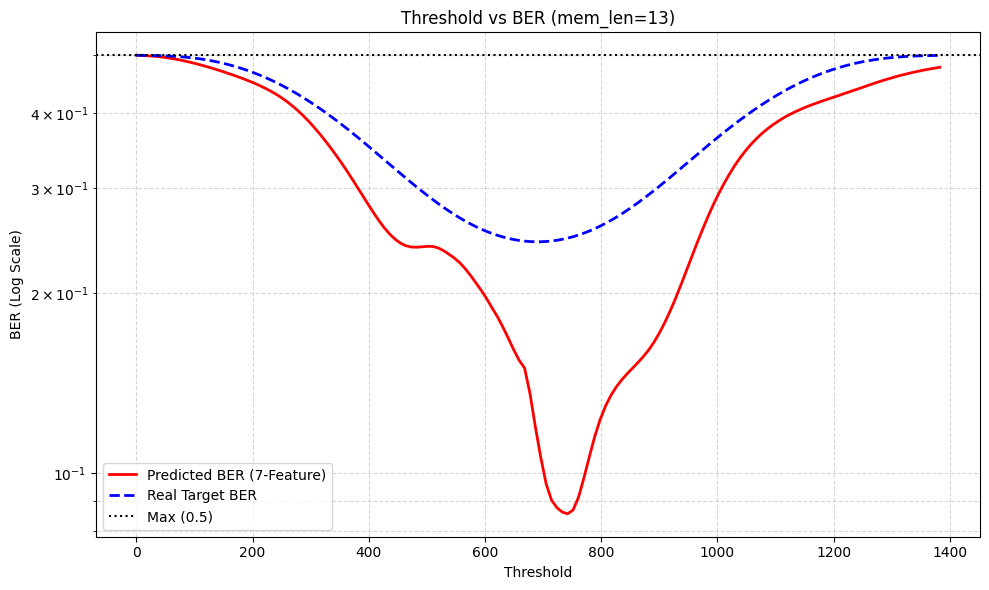

In [5]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.special import erfc
from itertools import product as iproduct

# =========================
# Configuration
# =========================
BASE_DIR = "./"
MODEL_PATH = os.path.join(BASE_DIR, "ber_boundedloghalf_globalboth_scratch_7feat_best_5M.pth")
SCALER_PATH = os.path.join(BASE_DIR, "ber_boundedloghalf_globalboth_scalers_scratch_7feat_5M.pkl")
EPS = 1e-12

# =========================
# Physics Helpers (For Real BER)
# =========================
def Fhit_function(radius, distance, diffusionCoef, t):
    if t <= 0:
        return 0.0
    return (radius / (distance + radius)) * erfc(distance / np.sqrt(4 * diffusionCoef * t))

def calculate_hitting_probabilities(mem_len, radius, distance, diffusionCoef, Ts):
    P = np.zeros(mem_len)
    for i in range(mem_len):
        t_end = (i + 1) * Ts
        t_start = i * Ts
        P[i] = Fhit_function(radius, distance, diffusionCoef, t_end) - Fhit_function(
            radius, distance, diffusionCoef, t_start
        )
    return P

def calculate_ber_vectorized(mem_len, threshold, P_scaled, variances):
    P_arr = np.asarray(P_scaled, dtype=float)[:mem_len]
    vars_arr = np.asarray(variances, dtype=float)[:mem_len]

    seqs = np.array(list(iproduct([0, 1], repeat=mem_len)), dtype=np.float64)[:, ::-1]
    c_bit = seqs[:, 0]

    mu = (seqs * P_arr).sum(axis=1)
    var_total = (seqs * vars_arr).sum(axis=1)
    std = np.sqrt(np.maximum(var_total, 0.0))

    pe = np.empty_like(mu)

    zero_std = (std == 0)
    if np.any(zero_std):
        pe[zero_std & (c_bit == 1)] = np.where(mu[zero_std & (c_bit == 1)] < threshold, 1.0, 0.0)
        pe[zero_std & (c_bit == 0)] = np.where(mu[zero_std & (c_bit == 0)] >= threshold, 1.0, 0.0)

    nz = ~zero_std
    if np.any(nz):
        pe[nz & (c_bit == 1)] = 0.5 * erfc((mu[nz & (c_bit == 1)] - threshold) / (std[nz & (c_bit == 1)] * np.sqrt(2)))
        pe[nz & (c_bit == 0)] = 0.5 * erfc((threshold - mu[nz & (c_bit == 0)]) / (std[nz & (c_bit == 0)] * np.sqrt(2)))

    return float(np.mean(pe))

def generate_physical_case(rng, min_mem_len=10, max_mem_len=14, arrival_coverage=0.70, max_tries=5000):
    for _ in range(max_tries):
        radius = rng.uniform(3.0, 5.0)
        distance = rng.uniform(10.0, 15.0)
        diff = rng.uniform(50.0, 75.0)
        Ts = rng.uniform(0.5, 1.2)
        N = int(10 ** rng.uniform(3.0, 6.0))

        f_inf = radius / (radius + distance)
        target = arrival_coverage * f_inf

        cumsum, k = 0.0, 0
        while k < max_mem_len:
            pk = Fhit_function(radius, distance, diff, (k + 1) * Ts) - Fhit_function(radius, distance, diff, k * Ts)
            cumsum += pk
            k += 1
            if cumsum >= target:
                break

        if k < min_mem_len:
            continue

        P_ext = calculate_hitting_probabilities(k + 1, radius, distance, diff, Ts)
        P_main = P_ext[:k]
        P_scaled = P_main * N
        variances = N * P_main * (1.0 - P_main)

        return {
            "radius": radius, "distance": distance, "diffusion": diff, "Ts": Ts, "N": N,
            "mem_len": k, "P": P_main, "P_scaled": P_scaled, "variances": variances
        }
    raise RuntimeError("Could not generate physical case.")

# =========================
# Architecture (Matches Training)
# =========================
class SqueezeExcite1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Conv1d(channels, hidden, 1), nn.GELU(), nn.Conv1d(hidden, channels, 1), nn.Sigmoid())
    def forward(self, x): return x * self.fc(self.pool(x))

class ConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1, stride=1, groups=1):
        super().__init__()
        padding = ((kernel_size - 1) // 2) * dilation
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, stride=stride, padding=padding, dilation=dilation, groups=groups, bias=False),
            nn.BatchNorm1d(out_ch), nn.GELU()
        )
    def forward(self, x): return self.block(x)

class MultiScaleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        b1, b2 = out_ch // 3, out_ch // 3
        b3 = out_ch - b1 - b2
        self.branch1 = ConvBNAct(in_ch, b1, 3, 1)
        self.branch2 = ConvBNAct(in_ch, b2, 5, 1)
        self.branch3 = ConvBNAct(in_ch, b3, 3, 2)
        self.mix = nn.Sequential(nn.Conv1d(out_ch, out_ch, 1, bias=False), nn.BatchNorm1d(out_ch), nn.GELU(), nn.Dropout(dropout))
        self.se = SqueezeExcite1D(out_ch) if se else nn.Identity()
        self.skip = nn.Sequential(nn.Conv1d(in_ch, out_ch, 1, bias=False), nn.BatchNorm1d(out_ch)) if in_ch != out_ch else nn.Identity()
        self.out_act = nn.GELU()
    def forward(self, x):
        res = self.skip(x)
        out = torch.cat([self.branch1(x), self.branch2(x), self.branch3(x)], dim=1)
        return self.out_act(self.se(self.mix(out)) + res)

class DownsampleResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.1, se=True):
        super().__init__()
        self.pre = MultiScaleResidualBlock(in_ch, out_ch, dropout, se)
        self.down = nn.Sequential(nn.Conv1d(out_ch, out_ch, 3, 2, 1, bias=False), nn.BatchNorm1d(out_ch), nn.GELU())
    def forward(self, x): return self.down(self.pre(x))

class ThresholdFiLM(nn.Module):
    def __init__(self, condition_dim, feature_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(condition_dim, hidden_dim), nn.GELU(), nn.Linear(hidden_dim, feature_dim * 2))
        self.scale = nn.Parameter(torch.tensor(0.25, dtype=torch.float32))
    def forward(self, x, cond):
        gamma, beta = torch.chunk(self.net(cond), 2, dim=1)
        return x * (1.0 + self.scale * gamma.unsqueeze(-1)) + self.scale * beta.unsqueeze(-1)

class SequenceStem(nn.Module):
    def __init__(self, in_ch, stem_ch=32):
        super().__init__()
        self.net = nn.Sequential(ConvBNAct(in_ch, stem_ch, 5), MultiScaleResidualBlock(stem_ch, stem_ch, 0.05, True))
    def forward(self, x): return self.net(x)

class LightSelfAttention1D(nn.Module):
    def __init__(self, dim, num_heads=4, mlp_ratio=2.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, int(dim * mlp_ratio)), nn.GELU(), nn.Dropout(dropout), nn.Linear(int(dim * mlp_ratio), dim), nn.Dropout(dropout))
    def forward(self, x):
        x_seq = x.transpose(1, 2)
        y = self.norm1(x_seq)
        attn_out, _ = self.attn(y, y, y, need_weights=False)
        x_seq = x_seq + attn_out
        return (x_seq + self.mlp(self.norm2(x_seq))).transpose(1, 2)

class MultiHeadAttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, num_heads=4):
        super().__init__()
        self.score = nn.Sequential(nn.Conv1d(input_dim, attn_dim, 1), nn.GELU(), nn.Conv1d(attn_dim, num_heads, 1))
        self.num_heads, self.in_dim = num_heads, input_dim
    def forward(self, x):
        weights = torch.softmax(self.score(x), dim=-1)
        return torch.einsum("bhl,bcl->bhc", weights, x).reshape(x.size(0), self.num_heads * self.in_dim)

class StagePooling(nn.Module):
    def __init__(self, channels, num_attn_heads=2, attn_dim=64):
        super().__init__()
        self.attn_pool = MultiHeadAttentionPooling(channels, attn_dim, num_attn_heads)
        self.out_dim = num_attn_heads * channels + 3 * channels
    def forward(self, x):
        return torch.cat([self.attn_pool(x), x.mean(dim=-1), x.std(dim=-1, unbiased=False), x.amax(dim=-1)], dim=1)

class BERMultiScaleResCNNBoundedLogHalf(nn.Module):
    def __init__(self, seq_len, threshold_dim=1, global_dim=7, stem_ch=32, channels=(64, 96, 128), dropout=0.10, stage_pool_heads=(2, 2, 2, 4), attn_heads=4, pos_emb_dim=8, use_self_attention=True):
        super().__init__()
        self.mean_stem = SequenceStem(1, stem_ch)
        self.var_stem = SequenceStem(1, stem_ch)
        self.extra_proj = nn.Sequential(nn.Conv1d(4, stem_ch, 1, bias=False), nn.BatchNorm1d(stem_ch), nn.GELU())
        self.pos_embedding = nn.Parameter(torch.randn(1, pos_emb_dim, seq_len) * 0.02)
        self.pos_emb_proj = nn.Sequential(nn.Conv1d(pos_emb_dim, stem_ch, 1, bias=False), nn.BatchNorm1d(stem_ch), nn.GELU())
        
        self.thr_embed = nn.Sequential(nn.Linear(threshold_dim, 32), nn.GELU(), nn.Linear(32, 32), nn.GELU())
        self.global_embed = nn.Sequential(nn.Linear(global_dim, 64), nn.GELU(), nn.Linear(64, 64), nn.GELU())
        
        cond_dim = 32 + 64
        self.stage1 = MultiScaleResidualBlock(stem_ch * 4, channels[0], dropout, True)
        self.film1 = ThresholdFiLM(cond_dim, channels[0], 96)
        self.stage2 = DownsampleResidualBlock(channels[0], channels[1], dropout, True)
        self.film2 = ThresholdFiLM(cond_dim, channels[1], 96)
        self.stage3 = DownsampleResidualBlock(channels[1], channels[2], dropout, True)
        self.film3 = ThresholdFiLM(cond_dim, channels[2], 96)
        
        self.self_attn = LightSelfAttention1D(channels[2], attn_heads, 2.0, dropout) if use_self_attention else nn.Identity()
        self.bottleneck = nn.Sequential(MultiScaleResidualBlock(channels[2], channels[2], dropout, True), MultiScaleResidualBlock(channels[2], channels[2], dropout, True))
        
        self.pool1 = StagePooling(channels[0], stage_pool_heads[0], 64)
        self.pool2 = StagePooling(channels[1], stage_pool_heads[1], 64)
        self.pool3 = StagePooling(channels[2], stage_pool_heads[2], 64)
        self.poolb = StagePooling(channels[2], stage_pool_heads[3], 128)
        
        head_in = self.pool1.out_dim + self.pool2.out_dim + self.pool3.out_dim + self.poolb.out_dim + cond_dim
        self.head = nn.Sequential(nn.Linear(head_in, 512), nn.GELU(), nn.Dropout(0.20), nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.15), nn.Linear(256, 128), nn.GELU(), nn.Linear(128, 1))

    @staticmethod
    def raw_to_log10ber(pred_raw_unconstrained):
        return torch.log10(torch.tensor(0.5, device=pred_raw_unconstrained.device)) - F.softplus(pred_raw_unconstrained)

    @staticmethod
    def raw_to_ber(pred_raw_unconstrained):
        return torch.pow(10.0, BERMultiScaleResCNNBoundedLogHalf.raw_to_log10ber(pred_raw_unconstrained)).clamp(min=EPS, max=0.5)

    def forward(self, seq, global_feats, threshold):
        x = torch.cat([self.mean_stem(seq[:, 0:1, :]), self.var_stem(seq[:, 1:2, :]), self.extra_proj(seq[:, 2:6, :]), self.pos_emb_proj(self.pos_embedding.expand(seq.size(0), -1, -1))], dim=1)
        cond = torch.cat([self.thr_embed(threshold), self.global_embed(global_feats)], dim=1)
        x3 = self.film3(self.stage3(self.film2(self.stage2(self.film1(self.stage1(x), cond)), cond)), cond)
        return self.head(torch.cat([self.pool1(self.film1(self.stage1(x), cond)), self.pool2(self.film2(self.stage2(self.film1(self.stage1(x), cond)), cond)), self.pool3(x3), self.poolb(self.bottleneck(self.self_attn(x3))), cond], dim=1))

# =========================
# Inference Engine (7 Features)
# =========================
# =========================
# Inference Engine (7 Features)
# =========================
def predict_ber_curve(model, scalers, taps, variances, N, thresholds, device="cpu"):
    model.eval()
    
    # 1. Pad sequences to exactly match the scaler's expected sequence length
    seq_len = scalers["seq_len"]
    
    if len(taps) < seq_len:
        taps = np.pad(taps, (0, seq_len - len(taps)), 'constant', constant_values=0.0)
        variances = np.pad(variances, (0, seq_len - len(variances)), 'constant', constant_values=0.0)
    elif len(taps) > seq_len:
        taps = taps[:seq_len]
        variances = variances[:seq_len]

    taps = np.array(taps, dtype=np.float32)
    variances = np.array(variances, dtype=np.float32)
    thresholds = np.array(thresholds, dtype=np.float32).reshape(-1, 1)
    
    L = len(taps) # Will now strictly equal seq_len (14)
    num_thrs = len(thresholds)
    
    # 2. Physics Calculations
    tap_feat = taps * N
    snr_raw = np.log10((tap_feat ** 2) / (variances + EPS) + EPS)
    abs_taps = np.abs(tap_feat)
    
    first_mean = tap_feat[0]
    mu0 = 0.5 * np.sum(tap_feat[1:])
    mu1 = first_mean + mu0
    
    first_var = variances[0]
    var0 = 0.5 * np.sum(variances[1:])
    var1 = first_var + var0
    
    std0 = np.sqrt(max(var0, EPS))
    std1 = np.sqrt(max(var1, EPS))
    
    # 3. Sequence Tiling
    t_tap_s = scalers["tap_scaler"].transform(taps.reshape(1, -1)).flatten()
    t_var_s = scalers["var_scaler"].transform(variances.reshape(1, -1)).flatten()
    t_abs_s = scalers["abs_scaler"].transform(abs_taps.reshape(1, -1)).flatten()
    t_snr_s = scalers["snr_scaler"].transform(snr_raw.reshape(1, -1)).flatten()
    
    pos = np.linspace(0.0, 1.0, L, dtype=np.float32)
    first_flag = np.zeros(L, dtype=np.float32)
    first_flag[0] = 1.0
    
    seq_single = np.stack([t_tap_s, t_var_s, pos, t_abs_s, t_snr_s, first_flag], axis=0)
    seq_batch = np.tile(seq_single, (num_thrs, 1, 1)).astype(np.float32)
    
    # 4. Target-Independent Global Features (3 out of 7)
    sir_raw = first_mean / (mu0 + EPS)
    vmr_raw = var0 / (mu0 + EPS)
    tail_snr_raw = first_mean / (std0 + EPS)
    
    sir_s = scalers["sir_scaler"].transform(np.full((num_thrs, 1), sir_raw, dtype=np.float32))
    vmr_s = scalers["vmr_scaler"].transform(np.full((num_thrs, 1), vmr_raw, dtype=np.float32))
    tail_snr_s = scalers["tail_snr_scaler"].transform(np.full((num_thrs, 1), tail_snr_raw, dtype=np.float32))
    
    # 5. Threshold-Dependent Global Features (4 out of 7)
    z0_raw = (thresholds - mu0) / (std0 + EPS)
    z1_raw = (mu1 - thresholds) / (std1 + EPS)
    msz_raw = np.minimum(z0_raw, z1_raw)
    harmonic_side_z_raw = 2.0 / (1.0 / (z0_raw + EPS) + 1.0 / (z1_raw + EPS))
    hmg_raw = harmonic_side_z_raw - 0.25 * np.abs(z0_raw - z1_raw)
    
    z0_s = scalers["z0_scaler"].transform(z0_raw)
    z1_s = scalers["z1_scaler"].transform(z1_raw)
    msz_s = scalers["min_side_z_scaler"].transform(msz_raw)
    hmg_s = scalers["harmonic_minus_gap_scaler"].transform(hmg_raw)
    
    # Concatenate all 7 features in proper order
    global_batch = np.concatenate([z0_s, z1_s, msz_s, hmg_s, sir_s, vmr_s, tail_snr_s], axis=1).astype(np.float32)
    thr_batch = scalers["thr_scaler"].transform(np.log10(thresholds + EPS)).astype(np.float32)
    
    # 6. Forward Pass
    with torch.no_grad():
        raw_preds = model(
            torch.from_numpy(seq_batch).to(device), 
            torch.from_numpy(global_batch).to(device), 
            torch.from_numpy(thr_batch).to(device)
        )
        ber_preds = model.raw_to_ber(raw_preds)
        
    return ber_preds.cpu().numpy().flatten()
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Loading Model and Scalers on {device}...")
    
    scalers = joblib.load(SCALER_PATH)
    seq_len = scalers["seq_len"]
    
    model = BERMultiScaleResCNNBoundedLogHalf(seq_len=seq_len, global_dim=7).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()

    # Create dummy scenario logic
    rng = np.random.default_rng(60)
    case = generate_physical_case(rng, min_mem_len=12, max_mem_len=14)
    
    thr_min = 0.0
    thr_max = float(np.sum(case["P_scaled"]))
    thresholds_to_test = np.linspace(thr_min, thr_max, 150)
    
    print("Running inference sweep for 7-feature model...")
    predicted_bers = predict_ber_curve(model, scalers, case["P"], case["variances"], case["N"], thresholds_to_test, device)
    
    real_bers = np.clip(np.array([
        calculate_ber_vectorized(case["mem_len"], thr, case["P_scaled"], case["variances"]) 
        for thr in thresholds_to_test
    ]), EPS, 0.5)

    best_est_idx = np.argmin(predicted_bers)
    print(f"Best estimated threshold: {thresholds_to_test[best_est_idx]:.2f} (BER: {predicted_bers[best_est_idx]:.2e})")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds_to_test, predicted_bers, label='Predicted BER (7-Feature)', color='red', linewidth=2)
    plt.plot(thresholds_to_test, real_bers, label='Real Target BER', color='blue', linestyle='--', linewidth=2)
    plt.yscale('log')
    plt.xlabel('Threshold')
    plt.ylabel('BER (Log Scale)')
    plt.title(f'Threshold vs BER (mem_len={case["mem_len"]})')
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.axhline(y=0.5, color='black', linestyle=':', label='Max (0.5)')
    plt.legend()
    plt.tight_layout()
    plt.show()